In [1]:
PSEUDOCOUNT = 0.143
THRESHOLD = 0.2

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('paper')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

plt.rcParams['svg.fonttype'] = 'none'

In [3]:
import warnings
import numpy as np
import pandas as pd

In [4]:
full_order = [
    'E. coli KFF-scrambled',
    'E. coli (ΔsbmA) KFF-scrambled',
    'E. coli D-KFF-scrambled',
    'E. coli (UPEC) KFF-scrambled',

    'K. pneumoniae KFF-scrambled',
    'S. enterica KFF-scrambled',

    'E. coli RXR-scrambled',
    'P. aeruginosa RXR-scrambled',
]

aso_order = ['KFF-scrambled',
             'D-KFF-scrambled', 'RXR-scrambled']

hue_order = ['E. coli', 'E. coli (ΔsbmA)',
             'E. coli (UPEC)',
             'K. pneumoniae',
             'S. enterica',
             'P. aeruginosa']

tab20 = sns.color_palette('tab20')
tab20c = sns.color_palette('tab20c')

palette = {'E. coli': tab20c[0],
           'E. coli (ΔsbmA)': tab20[6],
           'E. coli (UPEC)': tab20c[12],
           'K. pneumoniae': tab20c[4],
           'S. enterica': tab20c[8],
           'P. aeruginosa': tab20[12]}

In [5]:
tags = {'A': ('RXR-scrambled', 'E. coli'),
        'B': ('D-KFF-scrambled', 'E. coli'),
        'C': ('KFF-scrambled', 'E. coli'),
        'D': ('KFF-scrambled', 'E. coli (ΔsbmA)'),
        'E': ('KFF-scrambled', 'E. coli (UPEC)'),
        'F': ('KFF-scrambled', 'K. pneumoniae'),
        'G': ('KFF-scrambled', 'S. enterica'),
        'H': ('RXR-scrambled', 'P. aeruginosa')}

In [6]:
def remove_zero(x, m):
    x['od'] = x['od'] - m[(m['aso'] == 'media control') &
                  (m['day'] == x.name[1])]['od'].dropna().mean()
    return x

def normalize(v, threshold=THRESHOLD, pseudocount=0.01):
    v = v.copy()
    
    # first time point is below the threshold
    # assume the strain was actual not there
    if v[v['log2(mic)'] == v['log2(mic)'].min()]['od'].mean() < threshold:
        v['x'] = np.nan
        v['y'] = np.nan
        
        return v

    x = v['log2(mic)'].values
    x = (x - x.min()) / (x.max() - x.min())
    y = v['od'].values
    y = (y - 0) / (0.8 - 0)
    v['x'] = x
    v['y'] = y
    
    # also log transform
    y = v['od'].values
    y = (y - 0) / (0.8 - 0)
    y[y <= pseudocount] = pseudocount
    y = np.log(y)
    y = (y - np.log(pseudocount)) / (np.log(0.8) - np.log(pseudocount))
    v['ln(y)'] = y
    
    return v

In [7]:
d_mic = {x: y for x, y in zip(list(range(1, 5)) + list(range(5, 9)) +
                              list(range(9, 13)) + list(range(13, 17)),
                              [0.5] * 4 + [1] * 4 + [2] * 4 + [4] * 4)}

In [8]:
m = pd.read_csv(f'../data/aso_evolution_scrambled_controls_updated.tsv.gz', sep='\t')

m['mic'] = [d_mic[x] for x in m['day'].values]
m['aso'] = [tags[x][0] for x in m['column'].values]
m['species'] = [tags[x][1] for x in m['column'].values]

m['aso'] = ['media' if str(x) == 'nan' and str(y) != 'nan'
            else z
            for x, y, z in m[['drug', 'strain', 'aso']].values]
m['aso'] = ['media control' if str(x) == 'nan' and str(y) == 'nan'
            else z
            for x, y, z in m[['drug', 'strain', 'aso']].values]
m['species'] = [np.nan if str(x) == 'nan' and str(y) == 'nan'
                else z
                for x, y, z in m[['drug', 'strain', 'species']].values]

m['log2(mic)'] = np.log2(m['mic'])

m = m.groupby(['aso', 'day']).apply(remove_zero,
                                    m=m,
                                    include_groups=False).reset_index()
# m = m.groupby(['treatment', 'sample', 'row', 'column', 'replicate']).apply(normalize)

In [9]:
m

,aso,day,level_2,column,row,strain,drug,conc,od,mic,species,log2(mic)
0,D-KFF-scrambled,1,13,B,2,k12,dkff,10.0,0.826250,0.5,E. coli,-1.0
1,D-KFF-scrambled,1,14,B,3,k12,dkff,10.0,0.834250,0.5,E. coli,-1.0
2,D-KFF-scrambled,1,15,B,4,k12,dkff,10.0,0.835250,0.5,E. coli,-1.0
3,D-KFF-scrambled,2,109,B,2,k12,dkff,10.0,0.891775,0.5,E. coli,-1.0
4,D-KFF-scrambled,2,110,B,3,k12,dkff,10.0,1.036775,0.5,E. coli,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1531,media control,16,1524,H,1,NaN,NaN,NaN,-0.002050,4.0,NaN,2.0
1532,media control,16,1528,H,5,NaN,NaN,NaN,-0.002050,4.0,NaN,2.0
1533,media control,16,1532,H,9,NaN,NaN,NaN,-0.001050,4.0,NaN,2.0
1534,media control,16,1534,H,11,NaN,NaN,NaN,-0.001050,4.0,NaN,2.0


In [10]:
m

,aso,day,level_2,column,row,strain,drug,conc,od,mic,species,log2(mic)
0,D-KFF-scrambled,1,13,B,2,k12,dkff,10.0,0.826250,0.5,E. coli,-1.0
1,D-KFF-scrambled,1,14,B,3,k12,dkff,10.0,0.834250,0.5,E. coli,-1.0
2,D-KFF-scrambled,1,15,B,4,k12,dkff,10.0,0.835250,0.5,E. coli,-1.0
3,D-KFF-scrambled,2,109,B,2,k12,dkff,10.0,0.891775,0.5,E. coli,-1.0
4,D-KFF-scrambled,2,110,B,3,k12,dkff,10.0,1.036775,0.5,E. coli,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1531,media control,16,1524,H,1,NaN,NaN,NaN,-0.002050,4.0,NaN,2.0
1532,media control,16,1528,H,5,NaN,NaN,NaN,-0.002050,4.0,NaN,2.0
1533,media control,16,1532,H,9,NaN,NaN,NaN,-0.001050,4.0,NaN,2.0
1534,media control,16,1534,H,11,NaN,NaN,NaN,-0.001050,4.0,NaN,2.0


In [11]:
lines = [(i + 1)
         for i in range(16)
         if (i + 1) % 4 == 0]

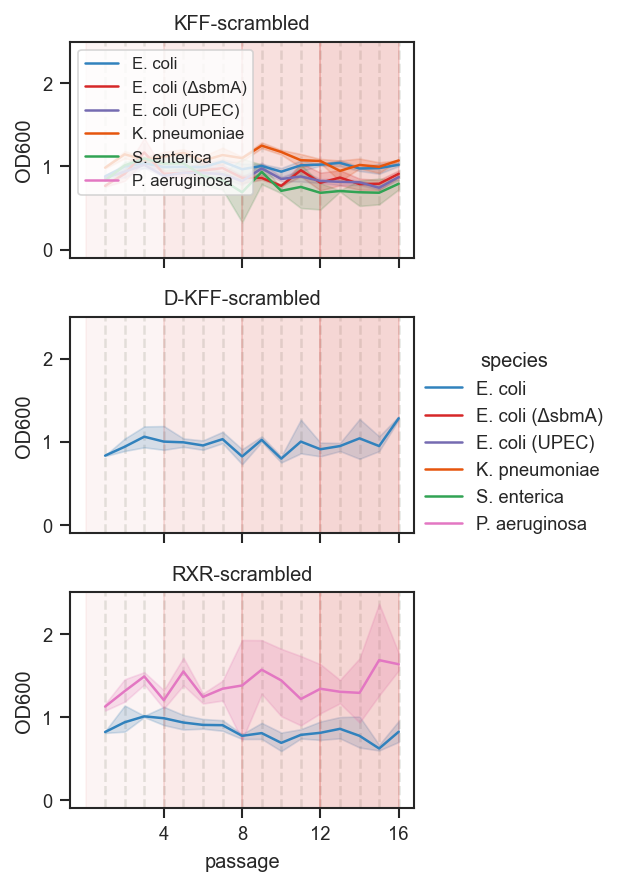

In [12]:
rp = sns.relplot(data=m,
                 x='day', y='od',
                 kind='line',
                 hue='species',
                 hue_order=hue_order,
                 palette=[palette[x] for x in hue_order],
                 col='aso', col_wrap=1,
                 col_order=aso_order,
                 height=2, aspect=1.6)

rp.axes.flatten()[0].legend(facecolor='w', fontsize=8)

rp.set_titles('{col_name}');
rp.set(ylabel='OD600',
       xlabel='passage',
       xticks=(lines),
       ylim=(-0.1, 2.5),
       )
for ax in rp.axes.flatten():
    for i in range(1, 17):
        ax.axvline(i, color='xkcd:light grey',
                   alpha=0.7,
                   ls='dashed',
                   zorder=-1)
    for i, v in enumerate(lines):
        ax.fill_between([v - 4, v],
                        [-1, -1],
                        [2.7, 2.7],
                        color='xkcd:pale red', alpha=0.06 * (i + 1))

sns.despine(top=False, right=False)

plt.savefig('od_readings_scrambled.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True)
plt.savefig('od_readings_scrambled.svg',
            dpi=300,
            bbox_inches='tight',
            transparent=True);

/home/marco/miniforge3/envs/2024_aso_evolution/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


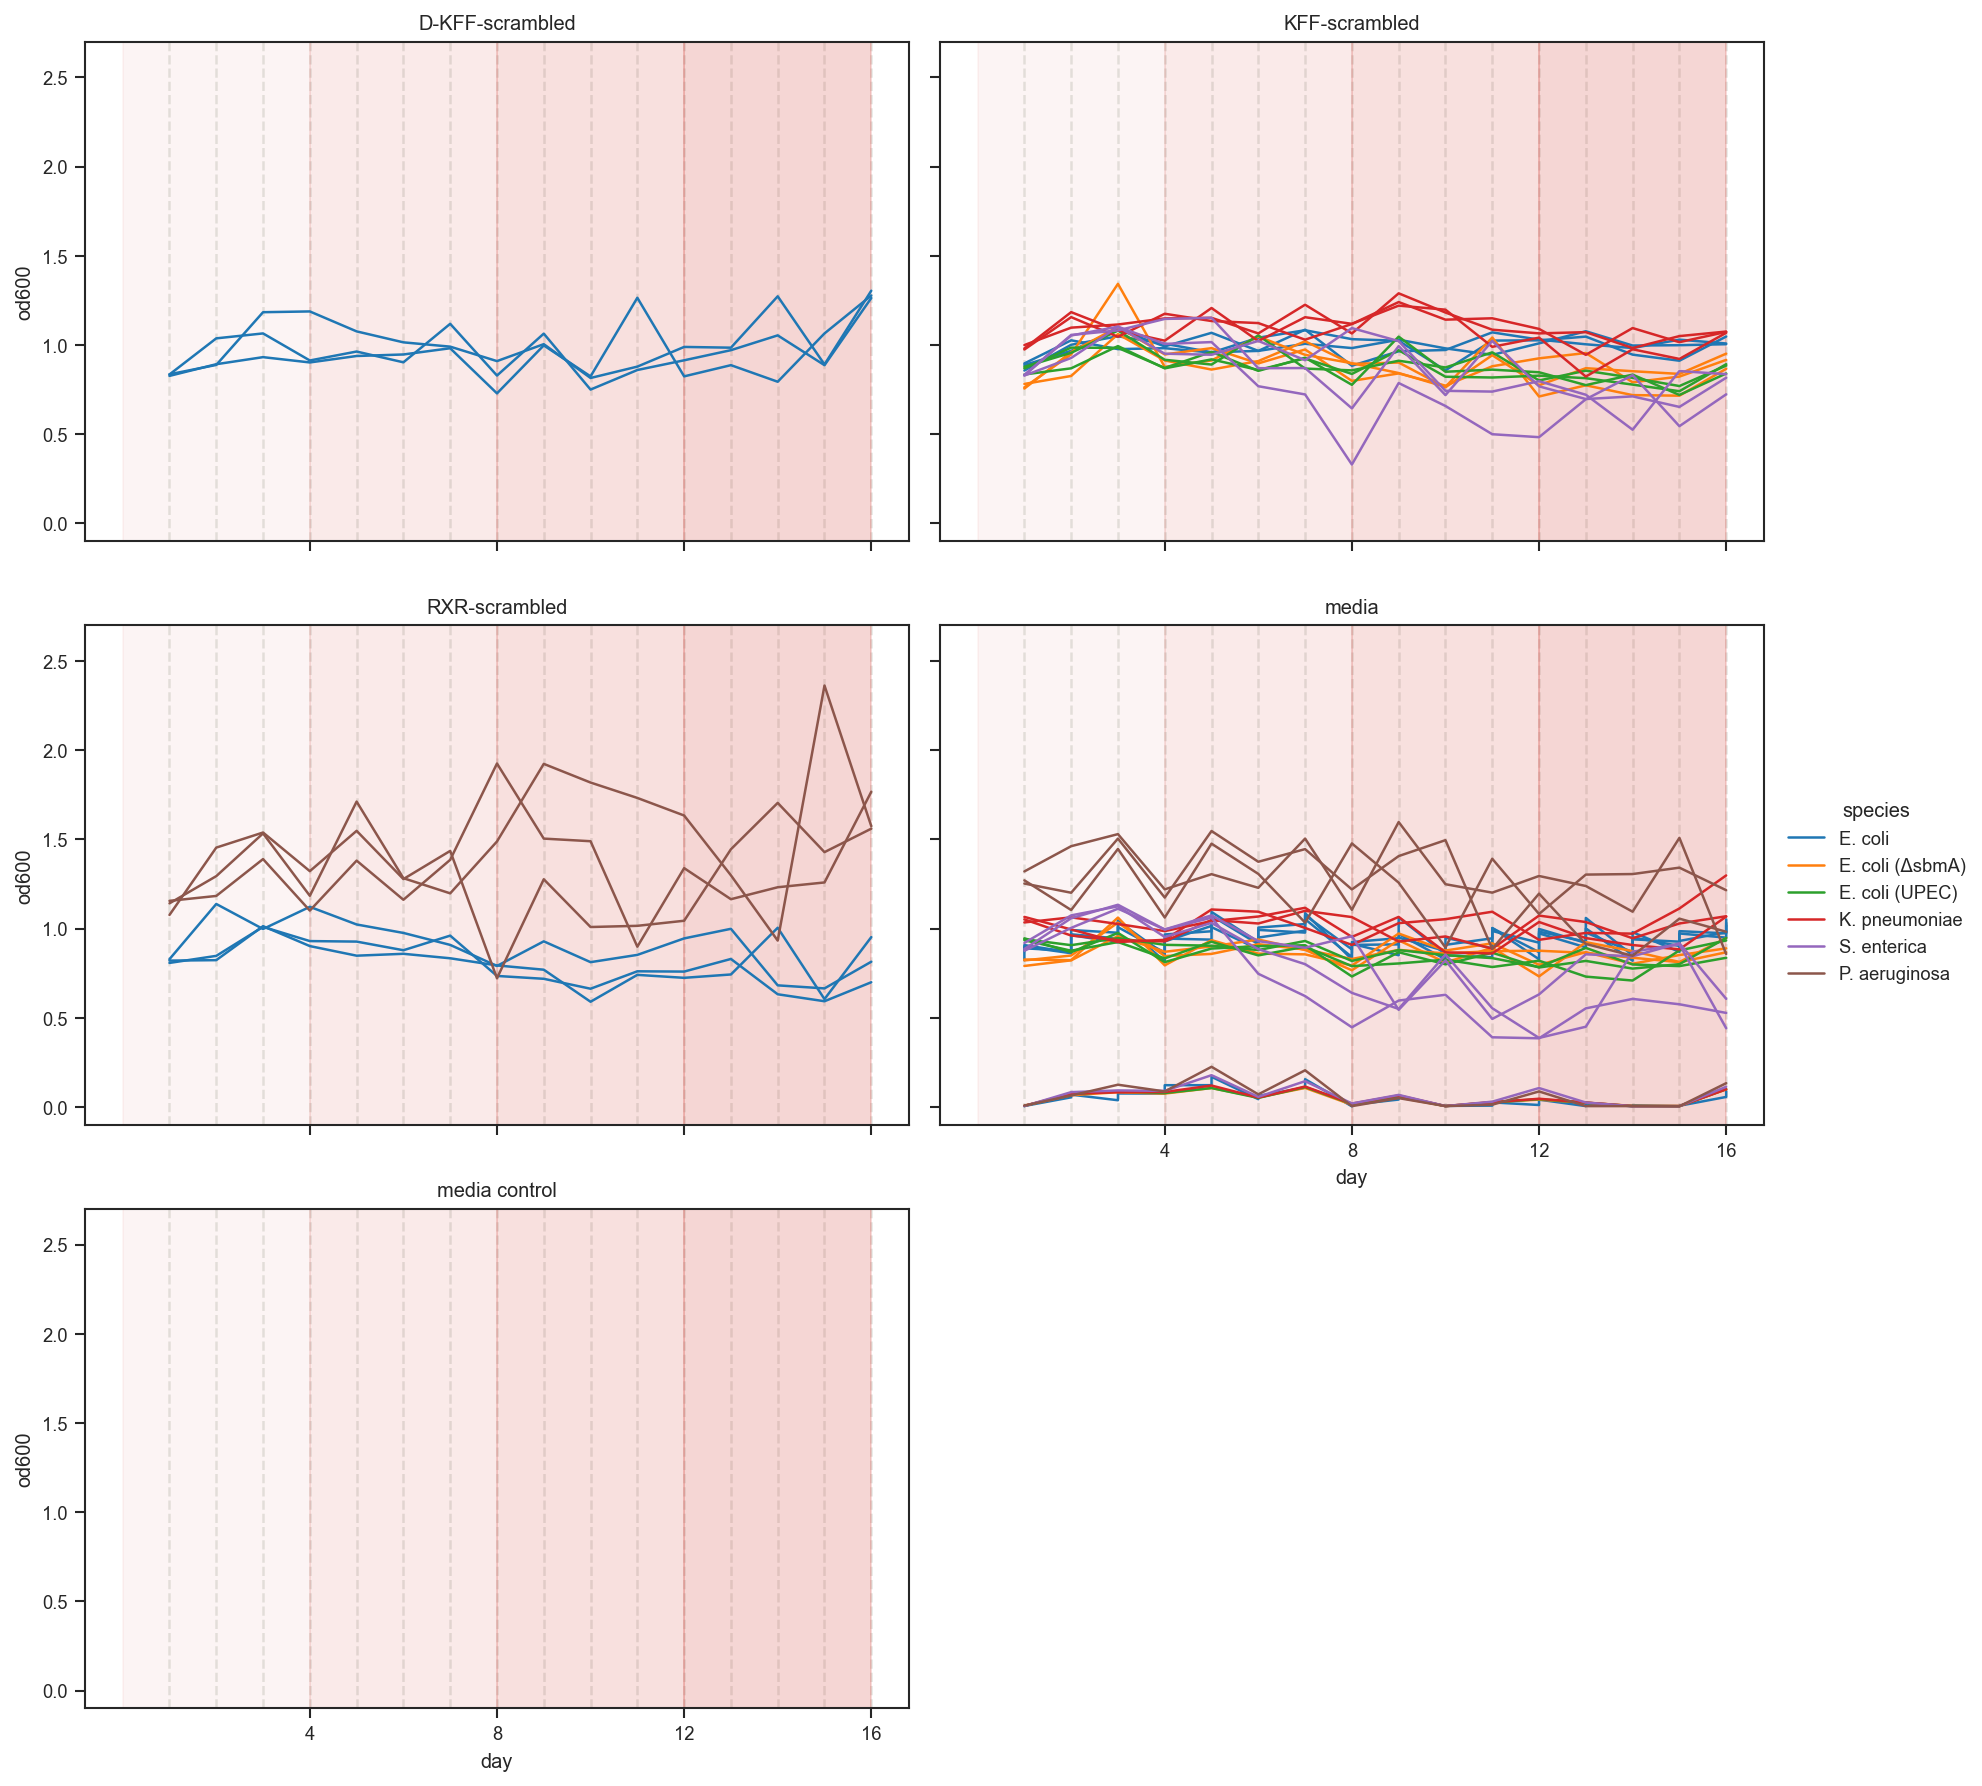

In [13]:
rp = sns.relplot(data=m,
                 x='day', y='od',
                 kind='line',
                 hue='species',
                 estimator=None,
                 units='row',
                 palette='tab10',
                 col='aso', col_wrap=2,
                 height=4, aspect=1.5)

rp.set_titles('{col_name}');
rp.set(ylabel='od600',
       xticks=(lines),
       ylim=(-0.1, 2.7),
       )
for ax in rp.axes.flatten():
    for i in range(1, 17):
        ax.axvline(i, color='xkcd:light grey',
                   alpha=0.7,
                   ls='dashed',
                   zorder=-1)
    for i, v in enumerate(lines):
        ax.fill_between([v - 4, v],
                        [-1, -1],
                        [3, 3],
                        color='xkcd:pale red', alpha=0.06 * (i + 1))

sns.despine(top=False, right=False);

In [14]:
m['full name'] = [f'{y} {x}' for x, y in m[['aso',
                                            'species']].values]

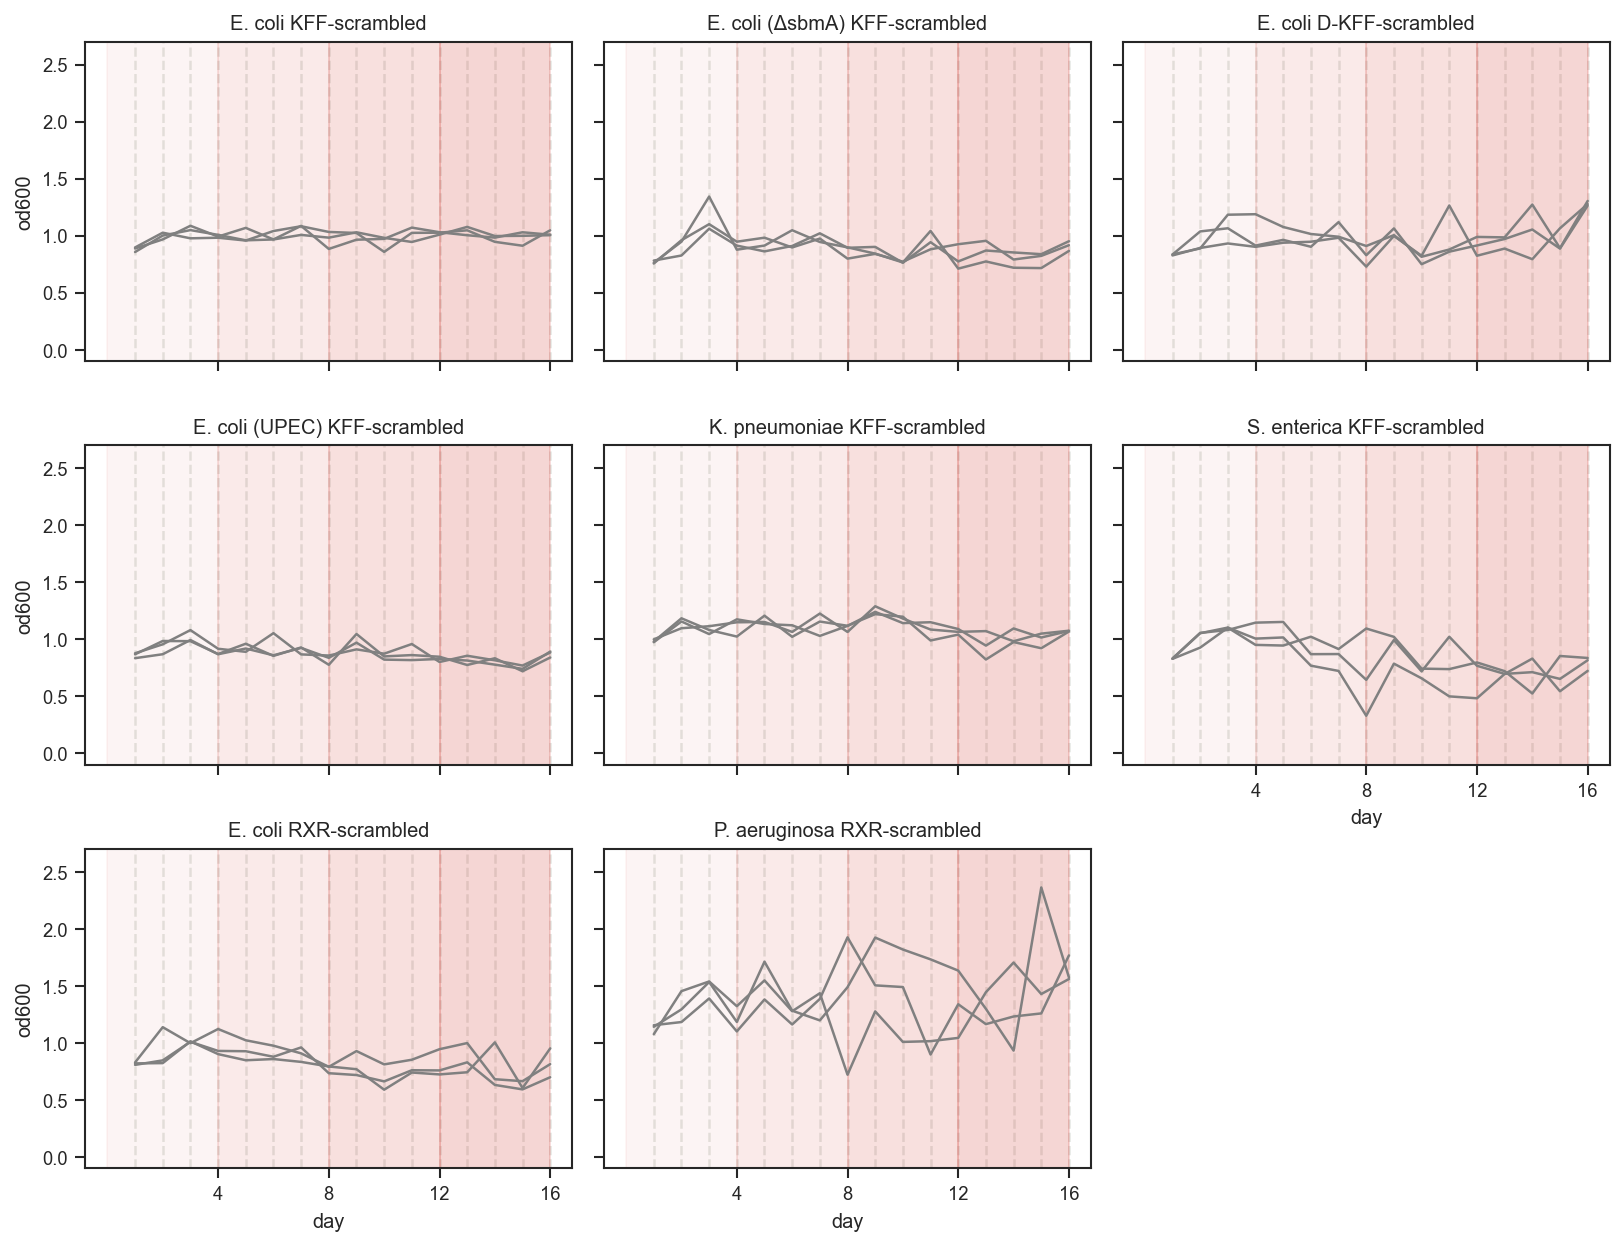

In [15]:
rp = sns.relplot(data=m[m['full name'] != 'nan nan'],
                 x='day', y='od',
                 kind='line',
                 # hue='aso',
                 estimator=None,
                 units='row',
                 color='grey',
                 col='full name', col_wrap=3,
                 height=2.8, aspect=1.3,
                 col_order=full_order)

rp.set_titles('{col_name}');
rp.set(ylabel='od600',
       xticks=(lines),
       ylim=(-0.1, 2.7),
       )
for ax in rp.axes.flatten():
    for i in range(1, 17):
        ax.axvline(i, color='xkcd:light grey',
                   alpha=0.7,
                   ls='dashed',
                   zorder=-1)
    for i, v in enumerate(lines):
        ax.fill_between([v - 4, v],
                        [-1, -1],
                        [3, 3],
                        color='xkcd:pale red', alpha=0.06 * (i + 1))

sns.despine(top=False, right=False)

plt.savefig('od_readings_full_scrambled.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True)
plt.savefig('od_readings_full_scrambled.svg',
            dpi=300,
            bbox_inches='tight',
            transparent=True);